In [12]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


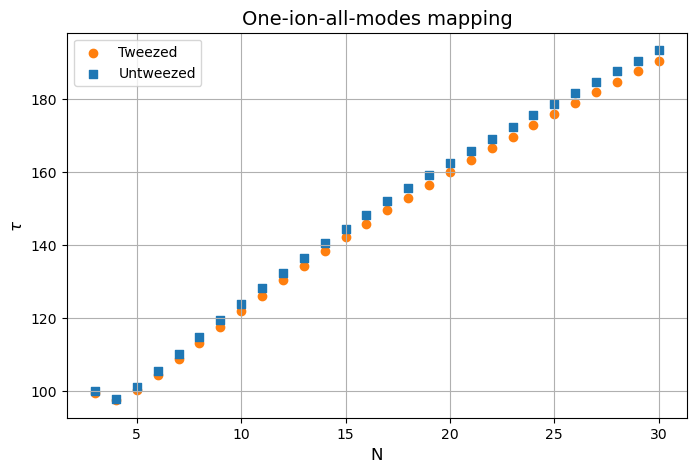

In [13]:
N = np.arange(3,4)
P = [1e-3]
w0 = 1e-6
f_rf_r = 3e6
f_rf_a = 0.125e6

dfs = []
many_N = []

for N in range(3, 31):
    test_loop = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)



# ...existing code...
dfs_untweezed = []
many_N_untweezed = []

for N in range(3, 31):
    test_loop = midcircuit_modes_untweezed(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)
# combine per-N DataFrames if not already done

combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

plt.figure(figsize=(8,5))
if Ns_t.size:
    plt.scatter(Ns_t, vals_t, marker='o', color='C1', label='Tweezed')
if Ns_u.size:
    plt.scatter(Ns_u, vals_u, marker='s', color='C0', label='Untweezed')
plt.xlabel("N",fontsize = 12)
plt.ylabel(r"$\tau$", fontsize=12)
plt.title("One-ion-all-modes mapping",fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

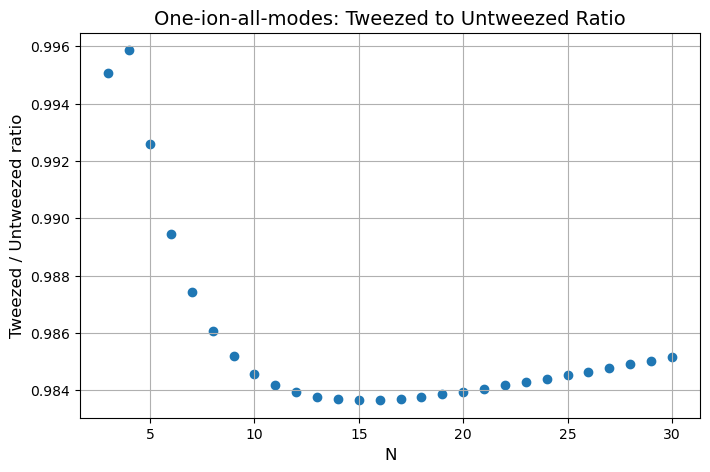

In [14]:
# Calculate ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratio_vals = []

for N in common_N:
    idx_t = np.where(Ns_t == N)[0]
    idx_u = np.where(Ns_u == N)[0]
    if len(idx_t) > 0 and len(idx_u) > 0:
        val_t = vals_t[idx_t[0]]
        val_u = vals_u[idx_u[0]]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = val_t / val_u if val_u != 0 else np.nan
        ratio_vals.append(ratio)
    else:
        ratio_vals.append(np.nan)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(common_N, ratio_vals, marker='o')
plt.xlabel("N", fontsize=12)
plt.ylabel(r"Tweezed / Untweezed ratio", fontsize=12)
plt.title("One-ion-all-modes: Tweezed to Untweezed Ratio", fontsize=14)
plt.grid(True)
#plt.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='Ratio = 1')
#plt.legend()
plt.show()

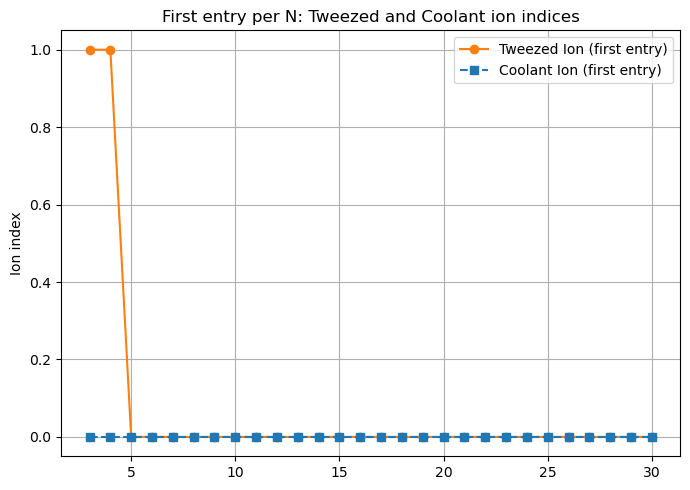

In [15]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _get_df_for_N(many, combined, N):
    if isinstance(many, list):
        for n, item in many:
            if n == N:
                if isinstance(item, pd.DataFrame):
                    return item.copy().reset_index(drop=True)
                return None
    if isinstance(combined, pd.DataFrame) and not combined.empty:
        tmp = combined[combined['N'] == N]
        if not tmp.empty:
            return tmp.copy().reset_index(drop=True)
    return None

many = globals().get('many_N')
combined = globals().get('combined_df')

if isinstance(many, list) and many:
    Ns = sorted({n for n, _ in many})
elif isinstance(combined, pd.DataFrame) and not combined.empty and 'N' in combined.columns:
    Ns = sorted(combined['N'].unique())
else:
    Ns = list(range(3, 30))

Ns = list(Ns)
first_t = []
first_c = []
second_t = []
second_c = []

for N in Ns:
    df = _get_df_for_N(many, combined, N)
    if df is None or df.empty:
        first_t.append(np.nan); first_c.append(np.nan)
        second_t.append(np.nan); second_c.append(np.nan)
        continue

    def safe_int(x):
        try:
            return int(x)
        except Exception:
            try:
                return int(float(x))
            except Exception:
                return np.nan

    # first entry (row 0)
    r0 = df.iloc[0]
    first_t.append(safe_int(r0.get('Tweezed Ion', np.nan)))
    first_c.append(safe_int(r0.get('Coolant Ion', np.nan)))

    # second entry (row 1) if available
    if len(df) > 1:
        r1 = df.iloc[1]
        second_t.append(safe_int(r1.get('Tweezed Ion', np.nan)))
        second_c.append(safe_int(r1.get('Coolant Ion', np.nan)))
    else:
        second_t.append(np.nan); second_c.append(np.nan)

# Plot
fig, axes = plt.subplots(1, 1, figsize=(7,5), sharex=True)

axes.plot(Ns, first_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (first entry)')
axes.plot(Ns, first_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (first entry)')
axes.set_ylabel('Ion index')
axes.set_title('First entry per N: Tweezed and Coolant ion indices')
axes.grid(True)
axes.legend()




plt.tight_layout()
plt.show()


In [16]:
list(zip(first_t, first_c))

[(1, 0),
 (1, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0)]

In [18]:
def sweep_power_and_find_minima(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    Ns_to_sweep,
    f_rf_r,
    f_rf_a,
    w0,
    power_values,
):
    """
    Sweep power values for given N values and find minimum tweezed/untweezed ratio.
    
    Parameters:
    -----------
    omega_tweezer, linewidths, omega_res, m, mode_calc_r : system parameters
    Ns_to_sweep : list of N values to evaluate
    f_rf_r, f_rf_a, w0 : RF and tweezer parameters
    power_values : array of power values (in watts) to sweep
    
    Returns:
    --------
    Dictionary with keys:
        't_vals': dict mapping N to list of tweezed metric values
        'u_vals': dict mapping N to list of untweezed metric values
        'ratio_vals': dict mapping N to list of ratio values
        'min_power_indices': dict mapping N to (min_power_mW, min_ratio)
        'power_values': the input power array for reference
    """
    
    def first_sum_by_N(df):
        if df is None or df.empty:
            return np.array([]), np.array([])
        first = df.groupby("N", sort=True, as_index=False).first()
        return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()
    
    # prepare containers per N
    t_vals = {N: [] for N in Ns_to_sweep}
    u_vals = {N: [] for N in Ns_to_sweep}
    ratio_vals = {N: [] for N in Ns_to_sweep}
    
    # sweep through power values
    for p in power_values:
        P_current = [p]
        for N_fixed in Ns_to_sweep:
            # tweezed
            test_loop = midcircuit_modes(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, f_rf_a, P_current, w0
            )
            if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
                df = test_loop.copy().reset_index(drop=True)
                df['N'] = int(N_fixed)
                try:
                    df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
                except Exception:
                    pass
                dfs = [df]
            else:
                dfs = []
            
            # untweezed
            test_loop_u = midcircuit_modes_untweezed(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, f_rf_a, P_current, w0
            )
            if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
                dfu = test_loop_u.copy().reset_index(drop=True)
                dfu['N'] = int(N_fixed)
                try:
                    dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
                except Exception:
                    pass
                dfs_untweezed = [dfu]
            else:
                dfs_untweezed = []
            
            combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
            combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()
            
            _, vals_t_arr = first_sum_by_N(combined_df)
            _, vals_u_arr = first_sum_by_N(combined_untweezed)
            
            val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
            val_u = vals_u_arr[0] if vals_u_arr.size else np.nan
            
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))
            
            t_vals[N_fixed].append(val_t)
            u_vals[N_fixed].append(val_u)
            ratio_vals[N_fixed].append(ratio)
    
    # Find minimum ratio for each N
    min_power_indices = {}
    for N_fixed in Ns_to_sweep:
        ratio_list = ratio_vals[N_fixed]
        min_ratio = np.nanmin(ratio_list)
        min_idx = np.nanargmin(ratio_list)
        min_power_mW = power_values[min_idx] * 1e3
        min_power_indices[N_fixed] = (min_power_mW, min_ratio)
    
    return {
        't_vals': t_vals,
        'u_vals': u_vals,
        'ratio_vals': ratio_vals,
        'min_power_indices': min_power_indices,
        'power_values': power_values,
    }

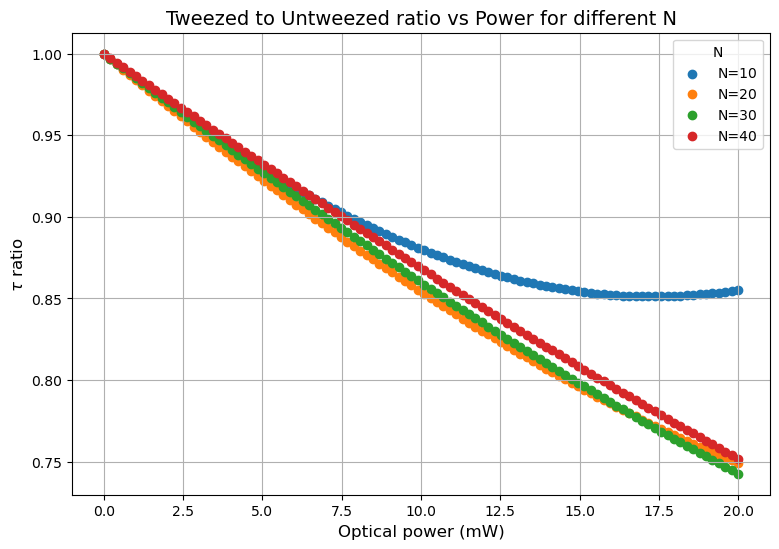

In [19]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6, 20e-3, 100)
Ns_to_plot = [10, 20, 30,40]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)


# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.scatter(powers_mW, ratio_vals[N_fixed], marker='o', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)",fontsize = 12)
plt.ylabel(r"$\tau$ ratio",fontsize = 12)
plt.title("Tweezed to Untweezed ratio vs Power for different N",fontsize = 14)
plt.grid(True)
plt.legend(title="N")
plt.show()

Minimum ratio for each N:
--------------------------------------------------
N=3: min ratio = 0.967749 at power = 12.1220 mW
N=4: min ratio = 0.977703 at power = 10.1018 mW
N=5: min ratio = 0.976520 at power = 5.5564 mW
N=6: min ratio = 0.949869 at power = 8.5867 mW
N=7: min ratio = 0.922868 at power = 11.1119 mW
N=8: min ratio = 0.897215 at power = 13.6371 mW
N=9: min ratio = 0.873322 at power = 15.6573 mW
N=10: min ratio = 0.851249 at power = 17.1724 mW
N=11: min ratio = 0.830889 at power = 19.1925 mW
N=12: min ratio = 0.812089 at power = 20.7077 mW
N=13: min ratio = 0.794695 at power = 22.2228 mW
N=14: min ratio = 0.778546 at power = 23.7379 mW
N=15: min ratio = 0.763513 at power = 25.2530 mW
N=16: min ratio = 0.749493 at power = 26.7681 mW
N=17: min ratio = 0.736329 at power = 27.7782 mW
N=18: min ratio = 0.723991 at power = 29.2933 mW
N=19: min ratio = 0.712360 at power = 30.3034 mW
N=20: min ratio = 0.701413 at power = 31.3135 mW
N=21: min ratio = 0.691022 at power = 32.8286 mW
N

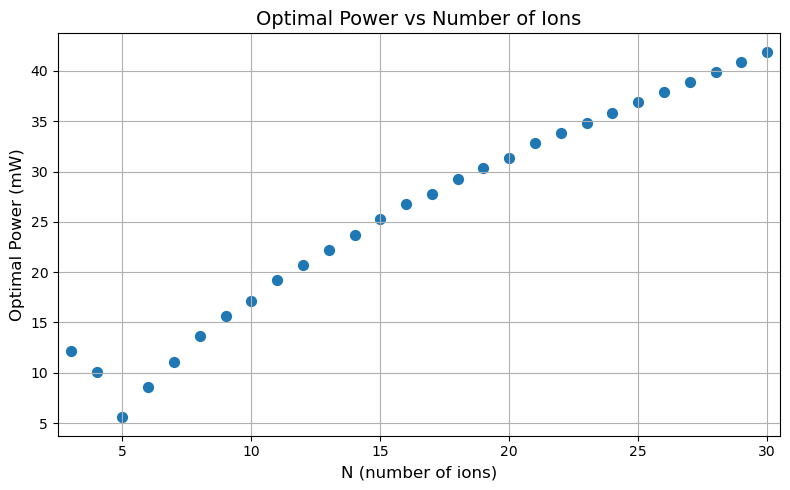

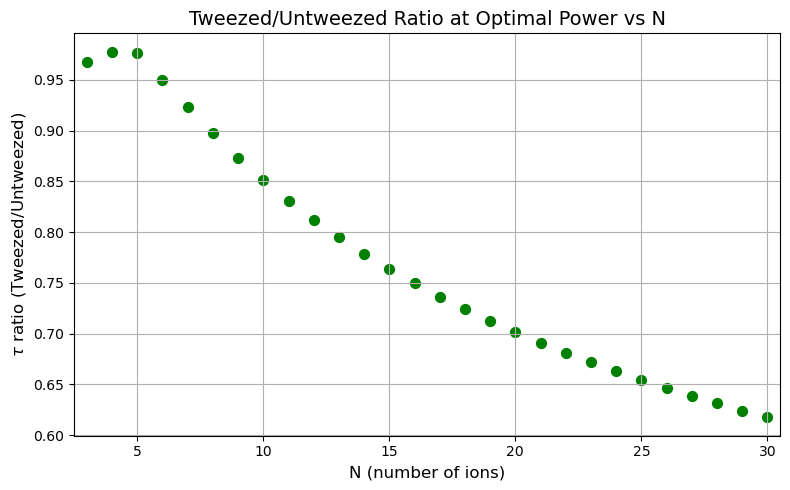

N	Optimal Power (mW)	Ratio at Optimal Power
--------------------------------------------------
3	12.1220		0.967749
4	10.1018		0.977703
5	5.5564		0.976520
6	8.5867		0.949869
7	11.1119		0.922868
8	13.6371		0.897215
9	15.6573		0.873322
10	17.1724		0.851249
11	19.1925		0.830889
12	20.7077		0.812089
13	22.2228		0.794695
14	23.7379		0.778546
15	25.2530		0.763513
16	26.7681		0.749493
17	27.7782		0.736329
18	29.2933		0.723991
19	30.3034		0.712360
20	31.3135		0.701413
21	32.8286		0.691022
22	33.8387		0.681185
23	34.8488		0.671850
24	35.8589		0.662972
25	36.8689		0.654509
26	37.8790		0.646428
27	38.8891		0.638699
28	39.8992		0.631297
29	40.9093		0.624199
30	41.9194		0.617386


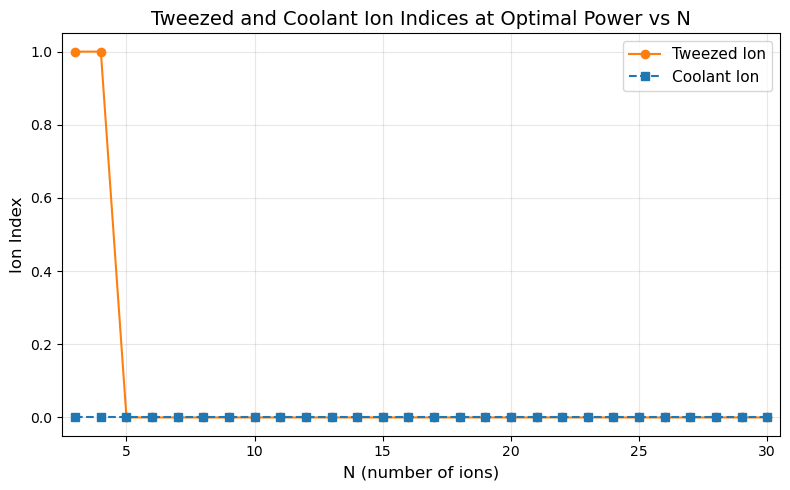

In [22]:
# Example usage: Sweep power and find minima for N=3-31
power_values = np.linspace(1e-6, 50e-3, 100)
Ns_to_sweep = np.arange(3, 31)

results = sweep_power_and_find_minima(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    Ns_to_sweep, f_rf_r, f_rf_a, w0, power_values
)

# Access the results:
t_vals = results['t_vals']
u_vals = results['u_vals']
ratio_vals = results['ratio_vals']
min_power_indices = results['min_power_indices']

# Extract optimal powers for each N
optimal_powers = {N: min_power_indices[N][0] for N in Ns_to_sweep}

# Print minima
print("Minimum ratio for each N:")
print("-" * 50)
for N in Ns_to_sweep:
    min_power, min_ratio = min_power_indices[N]
    print(f"N={N}: min ratio = {min_ratio:.6f} at power = {min_power:.4f} mW")

print("\n")

# ============================================================
# Plot 1: Optimal power vs N
Ns_plot = np.array(list(optimal_powers.keys()))
powers_mW_plot = np.array(list(optimal_powers.values()))

plt.figure(figsize=(8, 5))
plt.scatter(Ns_plot, powers_mW_plot, marker='o', color='C0', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Optimal Power (mW)", fontsize=12)
plt.title("Optimal Power vs Number of Ions", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Ratio at optimal power vs N

# Convert optimal powers to watts for function call
optimal_powers_W = {N: p / 1e3 for N, p in optimal_powers.items()}

dfs = []
dfs_untweezed = []

# Iterate over N and use the optimal P value found for each N
for N in Ns_to_sweep:
    P = optimal_powers_W[N]
    P_current = [P]
    
    # Tweezed
    test_loop = midcircuit_modes(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, f_rf_a, P_current, w0
    )
    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        dfs.append(df)
    
    # Untweezed
    test_loop_u = midcircuit_modes_untweezed(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, f_rf_a, P_current, w0
    )
    if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
        dfu = test_loop_u.copy().reset_index(drop=True)
        dfu['N'] = int(N)
        try:
            dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
        except Exception:
            pass
        dfs_untweezed.append(dfu)

# Combine DataFrames
combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

# Calculate the ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratios = [vals_t[np.where(Ns_t == N)[0][0]] / vals_u[np.where(Ns_u == N)[0][0]] for N in common_N]

# Plot: Ratio at optimal power vs N
plt.figure(figsize=(8, 5))
plt.scatter(common_N, ratios, marker='o', color='green', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.title("Tweezed/Untweezed Ratio at Optimal Power vs N", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Print summary table
print("N\tOptimal Power (mW)\tRatio at Optimal Power")
print("-" * 50)
for N in common_N:
    opt_power = optimal_powers[N]
    ratio_val = ratios[common_N.index(N)]
    print(f"{N}\t{opt_power:.4f}\t\t{ratio_val:.6f}")

# ============================================================
# Plot 3: Tweezed Ion and Coolant Ion vs N

tweezed_ions = []
coolant_ions = []
Ns_with_data = []

# Extract tweezed and coolant ions from combined_df
for N in Ns_to_sweep:
    subset = combined_df[combined_df['N'] == N]
    if not subset.empty:
        # Get the first entry for this N
        first_row = subset.iloc[0]
        tweezed_ion = first_row['Tweezed Ion']
        coolant_ion = first_row['Coolant Ion']
        
        # Safely convert to int
        try:
            tweezed_ions.append(int(tweezed_ion) if not pd.isna(tweezed_ion) else np.nan)
        except Exception:
            tweezed_ions.append(np.nan)
        
        try:
            coolant_ions.append(int(coolant_ion) if not pd.isna(coolant_ion) else np.nan)
        except Exception:
            coolant_ions.append(np.nan)
        
        Ns_with_data.append(N)

# Plot tweezed and coolant ions vs N
plt.figure(figsize=(8, 5))
plt.plot(Ns_with_data, tweezed_ions, marker='o', linestyle='-', color='C1', 
         label='Tweezed Ion', markersize=6)
plt.plot(Ns_with_data, coolant_ions, marker='s', linestyle='--', color='C0', 
         label='Coolant Ion', markersize=6)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Ion Index", fontsize=12)
plt.title("Tweezed and Coolant Ion Indices at Optimal Power vs N", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# Using optimal power for N=10 to make a verticle color bar table

In [23]:
N = 20
P = 100e-3
N10Test = midcircuit_modes(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     f_rf_a,
                     P,
                     w0
                     )

In [24]:
print(N10Test)

   Tweezed Ion  Coolant Ion                                                        Mode couplings                                      inverse_mode_couplings  sum_inverse_middle
0          5.0            0  [-0.012434478750501769, -0.014385535582425007, -0.03234901810595006]  [80.42154561240832, 69.51426968222947, 30.912839354962266]          180.848655
